# Modeling Baselines

### Imports

In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

from life_expectancy.data.preprocessing import build_processed_dataset
from life_expectancy.features.feature_engineering import prepare_numeric_model_frame
from life_expectancy.features.feature_selection import build_feature_sets_abc
from life_expectancy.modeling.experiments.core import run_time_experiment
from life_expectancy.modeling.model.baselines import (
    baseline_mean,
    elasticnet_cv,
    lasso_cv,
    linear_regression,
    ridge_cv,
)
from life_expectancy.modeling.pipelines import (
    build_model_pipeline,
    build_preprocessor,
    infer_feature_types,
)
from life_expectancy.modeling.splits import (
    filter_countries_min_years,
    make_random_split,
)
from life_expectancy.modeling.train_eval import results_to_dataframe, train_eval

### Verifying Project Root

In [43]:
from life_expectancy.data.utils import resolve_project_path


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = config.get("random_seed", 42)
TARGET = config["features"].get("target_col", "life_expectancy")
YEAR_COL = config["features"].get("year_col", "year")

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED)
print("Target:", TARGET)

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Processed dir: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed
Target: life_expectancy


### Loading Dataset

In [44]:
panel, preprocessing_summary = build_processed_dataset(config)

panel.head(), panel.shape

(       country  year      status  life_expectancy_who  adult_mortality  \
 0  Afghanistan  2015  Developing                 65.0            263.0   
 1  Afghanistan  2014  Developing                 59.9            271.0   
 2  Afghanistan  2013  Developing                 59.9            268.0   
 3  Afghanistan  2012  Developing                 59.5            272.0   
 4  Afghanistan  2011  Developing                 59.2            275.0   
 
    infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles  ...  \
 0             62     0.01               71.279624         65.0      100  ...   
 1             64     0.01               73.523582         62.0      100  ...   
 2             66     0.01               73.219243         64.0      100  ...   
 3             69     0.01               78.184215         67.0      100  ...   
 4             71     0.01                7.097109         68.0      100  ...   
 
            co2  health_expenditure_percent  education_expen

### Basic Assertions

In [45]:
assert TARGET in panel.columns
assert "country" in panel.columns
assert YEAR_COL in panel.columns

panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="raise").astype(int)

panel[[TARGET, "country", YEAR_COL]].head()

,life_expectancy,country,year
0,64.1885,Afghanistan,2015
1,61.4330,Afghanistan,2014
2,61.2125,Afghanistan,2013
3,60.7770,Afghanistan,2012
4,60.3765,Afghanistan,2011


## Leakage & ID columns to drop

In [46]:
leakage_cols = ["life_expectancy_who", "life_expectancy_wb"]
id_cols = ["country_code"]  # keep for diagnostics only, not predictors
# keep region/income_group for error analysis later, but decide if you want them as features
group_cols = ["region", "income_group"]  # for grouping diagnostics

### Building modeling dataframe (dropping target NAs; dropping leakage; choosing predictors)

In [47]:
model_df = prepare_numeric_model_frame(panel, config)

model_df.head(), model_df.shape

(   year  adult_mortality  infant_deaths  alcohol  percentage_expenditure  \
 0  2015            263.0             62     0.01               71.279624   
 1  2014            271.0             64     0.01               73.523582   
 2  2013            268.0             66     0.01               73.219243   
 3  2012            272.0             69     0.01               78.184215   
 4  2011            275.0             71     0.01                7.097109   
 
    hepatitis_b  measles   bmi  under_five_deaths  polio  ...  gdp_log1p  \
 0         65.0      100  19.1                 83    6.0  ...   6.372055   
 1         62.0      100  18.6                 86   58.0  ...   6.419501   
 2         64.0      100  18.1                 89   62.0  ...   6.450067   
 3         67.0      100  17.6                 93   67.0  ...   6.508708   
 4         68.0      100  17.2                 97   68.0  ...   4.167242   
 
    population_log1p  co2_log1p  gdp_missing_flag  schooling_missing_flag  \
 

In [48]:
# predictors start = everything except target
X_df = model_df.drop(columns=[TARGET], errors="ignore").copy()

# remove leakage and identifiers
X_df = X_df.drop(columns=[c for c in leakage_cols if c in X_df.columns], errors="ignore")
X_df = X_df.drop(columns=[c for c in id_cols if c in X_df.columns], errors="ignore")

# decide whether to keep year as a feature:
KEEP_YEAR = True
if not KEEP_YEAR and YEAR_COL in X_df.columns:
    X_df = X_df.drop(columns=[YEAR_COL])

# status encoding 
if "status" in X_df.columns:
    X_df["status_flag"] = (X_df["status"].astype(str).str.lower().str.contains("developed")).astype(int)
    # drop original text status from predictors
    X_df = X_df.drop(columns=["status"])

# Rebuild final modeling df with X + y + ids for later
final_df = X_df.copy()
final_df[TARGET] = model_df[TARGET].values

# Add ids back *only* for later inspection/plots (not as predictors)
for c in ["country", "country_code", "region", "income_group", YEAR_COL]:
    if c in model_df.columns and c not in final_df.columns:
        final_df[c] = model_df[c].values

final_df.shape, final_df.columns[:10]

((2265, 40),
 Index(['year', 'adult_mortality', 'infant_deaths', 'alcohol',
        'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi',
        'under_five_deaths', 'polio'],
       dtype='str'))

### Numeric vs Categorical

In [49]:
# numeric predictors only (for a clean first pass)
predictor_cols = [c for c in final_df.columns if c not in [TARGET, "country", "country_code", "region", "income_group"]]

X_only = final_df[predictor_cols].copy()

numeric_cols = X_only.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_only.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_cols, categorical_cols

(['year',
  'adult_mortality',
  'infant_deaths',
  'alcohol',
  'percentage_expenditure',
  'hepatitis_b',
  'measles',
  'bmi',
  'under_five_deaths',
  'polio',
  'total_expenditure',
  'diphtheria',
  'hiv_aids',
  'gdp',
  'population',
  'thinness_1_19_years',
  'thinness_5_9_years',
  'income_composition_of_resources',
  'schooling',
  'undernourishment',
  'co2',
  'health_expenditure_percent',
  'education_expenditure_percent',
  'unemployment',
  'corruption',
  'sanitation',
  'injuries',
  'communicable',
  'noncommunicable_disease',
  'status_flag',
  'gdp_log1p',
  'population_log1p',
  'co2_log1p',
  'gdp_missing_flag',
  'schooling_missing_flag',
  'sanitation_missing_flag',
  'adult_mortality_missing_flag',
  'schooling__x__status_flag',
  'gdp_log1p__x__status_flag'],
 [])

### Feature Sets (Full vs Reduced)

In [50]:
model_df, feature_sets, feature_meta = build_feature_sets_abc(panel, config)

FEATURES_FULL = feature_sets["A"]
FEATURES_REDUCED = feature_sets["B"]
FEATURES_INTERPRETABLE = feature_sets["C"]

print("Full:", len(FEATURES_FULL))
print("Reduced:", len(FEATURES_REDUCED))
print("Interpretable:", len(FEATURES_INTERPRETABLE))

Full: 38
Reduced: 31
Interpretable: 5


### Model Runner Helper

In [51]:
def run_models_on_split(
    split_name,
    x_train,
    x_test,
    y_train,
    y_test,
    feature_list,
):
    results = []
    prediction_dfs = {}

    x_train_model = x_train[feature_list].copy()
    x_test_model = x_test[feature_list].copy()

    numeric_cols, categorical_cols = infer_feature_types(x_train_model)

    preprocessor = build_preprocessor(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        scale_numeric="standard",
    )

    models = {
        "MeanBaseline": baseline_mean(),
        "Linear": linear_regression(),
        "RidgeCV": ridge_cv(),
        "LassoCV": lasso_cv(random_state=RANDOM_SEED),
        "ElasticNetCV": elasticnet_cv(random_state=RANDOM_SEED),
    }

    for name, model in models.items():
        pipeline = build_model_pipeline(
            model=model,
            preprocessor=preprocessor,
        )

        result, pred_df = train_eval(
            pipeline,
            x_train_model,
            y_train,
            x_test_model,
            y_test,
            model_name=name,
            split_name=split_name,
            return_predictions_df=True,
        )

        results.append(result)
        prediction_dfs[name] = pred_df

    return results, prediction_dfs


## Random Split Results (Full vs Reduced)

In [52]:
x_train, x_test, y_train, y_test, random_info = make_random_split(
    model_df,
    target_col=TARGET,
    test_size=0.2,
    seed=RANDOM_SEED,
)

res_full_rand, preds_full_rand = run_models_on_split(
    "random_full",
    x_train,
    x_test,
    y_train,
    y_test,
    FEATURES_FULL,
)

res_reduced_rand, preds_reduced_rand = run_models_on_split(
    "random_reduced",
    x_train,
    x_test,
    y_train,
    y_test,
    FEATURES_REDUCED,
)

df_results_rand = results_to_dataframe(
    res_full_rand + res_reduced_rand
).sort_values(["split_name", "rmse"])

df_results_rand

,model_name,split_name,n_train,n_test,rmse,mae,r2
1,Linear,random_full,1812,453,3.353319,2.537908,0.887350
2,RidgeCV,random_full,1812,453,3.353763,2.539175,0.887320
4,ElasticNetCV,random_full,1812,453,3.393719,2.596542,0.884620
3,LassoCV,random_full,1812,453,3.510327,2.666965,0.876554
0,MeanBaseline,random_full,1812,453,9.992520,8.156092,-0.000301
6,Linear,random_reduced,1812,453,3.447294,2.628693,0.880948
7,RidgeCV,random_reduced,1812,453,3.448192,2.630311,0.880886
9,ElasticNetCV,random_reduced,1812,453,3.453808,2.634136,0.880498
8,LassoCV,random_reduced,1812,453,3.526107,2.671481,0.875442
5,MeanBaseline,random_reduced,1812,453,9.992520,8.156092,-0.000301


## Time split results (Full vs Reduced)

In [53]:
from life_expectancy.modeling.splits import make_time_split


x_train, x_test, y_train, y_test, time_info = make_time_split(
    model_df,
    target_col=TARGET,
    year_col=YEAR_COL,
    test_years=3
)

res_full_time, preds_full_time = run_models_on_split(
    "time_full",
    x_train,
    x_test,
    y_train,
    y_test,
    FEATURES_FULL,
)

res_reduced_time, preds_reduced_time = run_models_on_split(
    "time_reduced",
    x_train,
    x_test,
    y_train,
    y_test,
    FEATURES_REDUCED,
)

df_results_time = results_to_dataframe(
    res_full_time + res_reduced_time
).sort_values(["split_name", "rmse"])

df_results_time

,model_name,split_name,n_train,n_test,rmse,mae,r2
3,LassoCV,time_full,1812,453,3.093671,2.454510,0.863430
4,ElasticNetCV,time_full,1812,453,3.106721,2.469682,0.862276
2,RidgeCV,time_full,1812,453,3.152573,2.503920,0.858180
1,Linear,time_full,1812,453,3.156877,2.506363,0.857793
0,MeanBaseline,time_full,1812,453,8.777449,7.563970,-0.099368
8,LassoCV,time_reduced,1812,453,3.107600,2.462052,0.862198
9,ElasticNetCV,time_reduced,1812,453,3.128734,2.483922,0.860317
7,RidgeCV,time_reduced,1812,453,3.132890,2.492661,0.859946
6,Linear,time_reduced,1812,453,3.135777,2.499813,0.859687
5,MeanBaseline,time_reduced,1812,453,8.777449,7.563970,-0.099368


In [54]:
balanced_panel = filter_countries_min_years(
    panel,
    country_col="country",
    year_col=YEAR_COL,
    min_years=5,
)

model_df_time = prepare_numeric_model_frame(balanced_panel, config)

baseline_models = {
    "MeanBaseline": {
        "model": baseline_mean(),
        "scale_numeric": "none",
    },
    "Linear": {
        "model": linear_regression(),
        "scale_numeric": "standard",
    },
    "RidgeCV": {
        "model": ridge_cv(),
        "scale_numeric": "standard",
    },
    "LassoCV": {
        "model": lasso_cv(random_state=RANDOM_SEED),
        "scale_numeric": "standard",
    },
    "ElasticNetCV": {
        "model": elasticnet_cv(random_state=RANDOM_SEED),
        "scale_numeric": "standard",
    },
}

In [55]:
time_rows = []
time_predictions = {}

for feature_set_name, feature_list in {
    "full": FEATURES_FULL,
    "reduced": FEATURES_REDUCED,
}.items():
    available_features = [col for col in feature_list if col in model_df_time.columns]

    for model_name, spec in baseline_models.items():
        row, pred_df, split_info, pipeline = run_time_experiment(
            df=model_df_time,
            feature_list=available_features,
            target_col=TARGET,
            year_col=YEAR_COL,
            model_name=model_name,
            model=spec["model"],
            scale_numeric=spec["scale_numeric"],
            test_years=3,
            split_label=f"time_{feature_set_name}",
            id_cols=[YEAR_COL],
        )

        time_rows.append(row)
        time_predictions[(feature_set_name, model_name)] = pred_df

df_results_time = pd.DataFrame(time_rows).sort_values(["split_name", "rmse"])

df_results_time

,model_name,split_name,n_train,n_test,rmse,mae,r2
3,LassoCV,time_full,1812,453,3.093671,2.454510,0.863430
4,ElasticNetCV,time_full,1812,453,3.106721,2.469682,0.862276
2,RidgeCV,time_full,1812,453,3.152573,2.503920,0.858180
1,Linear,time_full,1812,453,3.156877,2.506363,0.857793
0,MeanBaseline,time_full,1812,453,8.777449,7.563970,-0.099368
8,LassoCV,time_reduced,1812,453,3.107600,2.462052,0.862198
9,ElasticNetCV,time_reduced,1812,453,3.128734,2.483922,0.860317
7,RidgeCV,time_reduced,1812,453,3.132890,2.492661,0.859946
6,Linear,time_reduced,1812,453,3.135777,2.499813,0.859687
5,MeanBaseline,time_reduced,1812,453,8.777449,7.563970,-0.099368


## One Combined Table

In [56]:
all_results = pd.concat([df_results_rand, df_results_time], ignore_index=True)
all_results = all_results.sort_values(["split_name","rmse"])
all_results

,model_name,split_name,n_train,n_test,rmse,mae,r2
0,Linear,random_full,1812,453,3.353319,2.537908,0.887350
1,RidgeCV,random_full,1812,453,3.353763,2.539175,0.887320
2,ElasticNetCV,random_full,1812,453,3.393719,2.596542,0.884620
3,LassoCV,random_full,1812,453,3.510327,2.666965,0.876554
4,MeanBaseline,random_full,1812,453,9.992520,8.156092,-0.000301
5,Linear,random_reduced,1812,453,3.447294,2.628693,0.880948
6,RidgeCV,random_reduced,1812,453,3.448192,2.630311,0.880886
7,ElasticNetCV,random_reduced,1812,453,3.453808,2.634136,0.880498
8,LassoCV,random_reduced,1812,453,3.526107,2.671481,0.875442
9,MeanBaseline,random_reduced,1812,453,9.992520,8.156092,-0.000301


### Saving Artifacts

In [57]:
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

all_results.to_csv(
    metrics_dir / "baseline_results.csv",
    index=False,
)

pd.Series(FEATURES_FULL).to_json(
    metrics_dir / "final_features_full.json",
    orient="values",
    indent=2,
)

pd.Series(FEATURES_REDUCED).to_json(
    metrics_dir / "final_features_reduced.json",
    orient="values",
    indent=2,
)

pd.Series(FEATURES_INTERPRETABLE).to_json(
    metrics_dir / "final_features_interpretable.json",
    orient="values",
    indent=2,
)

print("Saved baseline results and feature lists to:", metrics_dir)

Saved baseline results and feature lists to: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/outputs/metrics


## Barplot for Time Aware Split

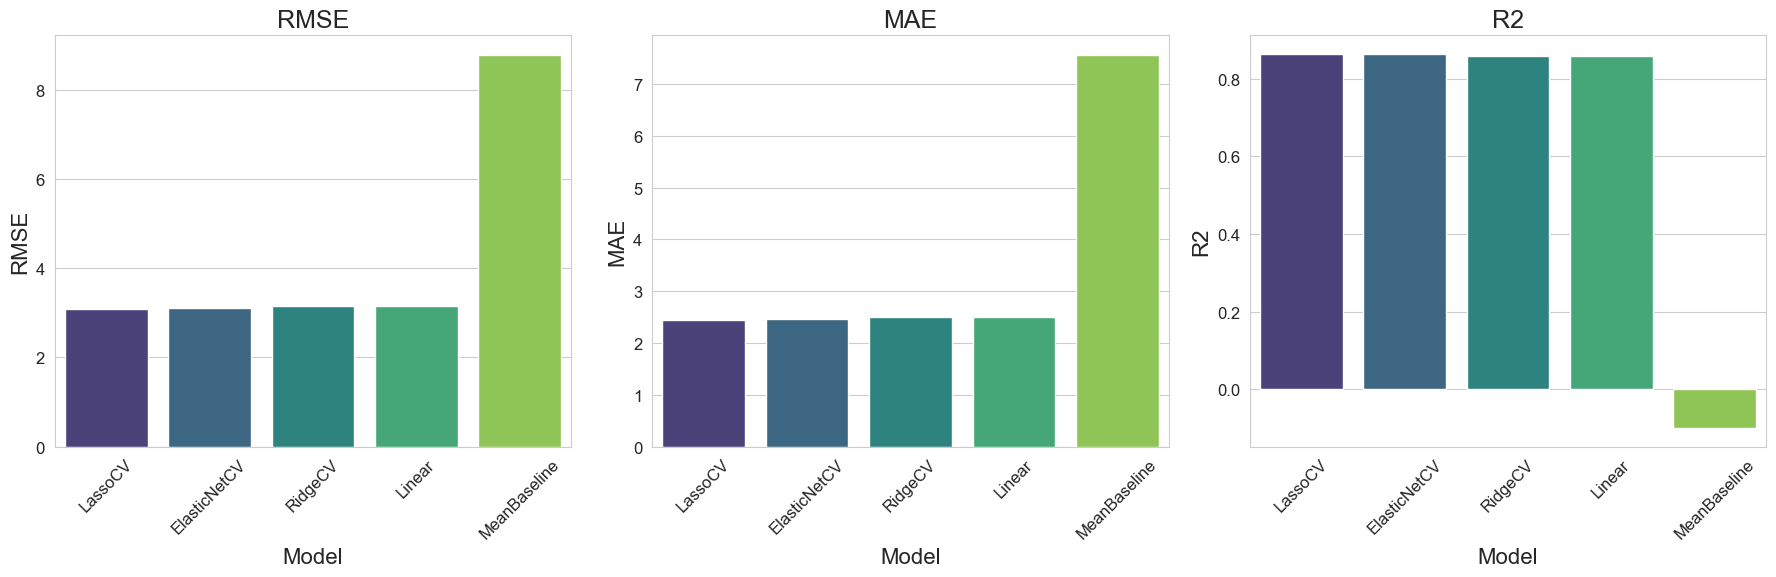

In [58]:
df_plot = all_results[all_results["split_name"] == "time_full"].copy()

sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

metrics = ["rmse", "mae", "r2"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for index, metric in enumerate(metrics):
    sns.barplot(
        data=df_plot,
        x="model_name",
        y=metric,
        hue="model_name",
        ax=axes[index],
        palette="viridis",
        legend=False,
    )
    axes[index].set_title(metric.upper())
    axes[index].set_xlabel("Model")
    axes[index].set_ylabel(metric.upper())
    axes[index].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()